# Noncollinear magnetism, magnetic fields and constrained moments

With `nspin_mag = 4` the magnetization is a **vector field** rather than a number
per point. Two things follow. The symmetry group shrinks, because a rotation has
to map the moments onto themselves as an *axial* vector and some operations
survive only in combination with time reversal. And there is now a direction to
constrain, or to push on, which is what magnetic fields and constrained moments
are for.

The density becomes a $2\times 2$ matrix in spin space, and the magnetization is
its projection onto the Pauli matrices:

$$n_{\alpha\beta}(\mathbf r) = \tfrac{1}{2}\Big[
   n(\mathbf r)\,\delta_{\alpha\beta}
   + \mathbf m(\mathbf r)\cdot\boldsymbol\sigma_{\alpha\beta} \Big],
\qquad
\mathbf m(\mathbf r) = \sum_{n\mathbf k} f_{n\mathbf k}\,
   \psi^{\dagger}_{n\mathbf k}(\mathbf r)\,
   \boldsymbol\sigma\,\psi_{n\mathbf k}(\mathbf r)$$

A constraint is a penalty on that vector, and the field it exerts is the
gradient of the penalty, taken rather than derived by hand:

$$E_{\rm pen} = \lambda \sum_I \big(\mathbf m_I - \mathbf m^{\rm fix}_I\big)^2,
\qquad
\mathbf B_I = -\frac{\partial E_{\rm pen}}{\partial \mathbf m_I}$$

On bcc iron, and on the constrained-moment cells QE ships:

| | pypresso | `pw.x` |
|---|---|---|
| bcc iron, LDA | **-55.69968434 Ry** | -55.69968434 |
| bcc iron, PBE | **-55.939445673 Ry** | -55.939445670 |
| its moment | **3.1763 $\mu_B$** | 3.18 |
| three constrained schemes | | agree to **2e-7 Ry** |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.io import comparison_table, read_qe_output

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite/pw_noncolin")
PSEUDO, REFS = Path("../tests/data/pseudo"), Path("../tests/data/qe")

iron = Calculator.from_file(QE / "noncolin.in", pseudo_dir=PSEUDO, conv_thr=1e-10)
scf = iron.get_scf()
qe = read_qe_output(REFS / "reference.out.pw_noncolin-noncolin")

print(f"moment   pypresso {np.round(scf.magnetization_vector, 4)}   pw.x {qe.magnetization_vector}")

moment   pypresso [ 3.1763  0.     -0.    ]   pw.x (3.18, -0.0, -0.0)


The moment came out along $x$, which is where the input put it, and with a
magnitude the code was not told: 3.18 Bohr magnetons is iron's answer, not an
input.

"The moment on this atom" has no exact meaning in a plane-wave code, because
there are no muffin tins to integrate over. What is reported is the
magnetization integrated over a sphere of the radius QE uses, which for iron
holds about 60% of the valence charge, and it matches QE's.

Run with PBE instead the total is -55.939445673 Ry against `pw.x`'s
-55.939445670, and the moment goes from 3.18 to **3.47** $\mu_B$, which is why a
magnetic comparison with the literature needs the gradient correction. A
gradient correction to a *vector* density is taken in the local spin frame: at
each point the density matrix is rotated onto its own magnetization axis, the
collinear expression is applied there, and the result is rotated back.

In [2]:
print(comparison_table(
    [(term, scf.energy_terms[term], value)
     for term, value in qe.energy_terms.items() if term in scf.energy_terms]
    + [("TOTAL", scf.total_energy, qe.total_energy)],
    fmt="{:.8f}", headers=("term [Ry]", "pypresso", "pw.x", "difference")))

term [Ry]         pypresso          pw.x  difference
one-electron    8.92933178    8.92932731     4.5e-06
hartree         6.13361506    6.13359228     2.3e-05
xc            -26.12190861  -26.12188165     2.7e-05
ewald         -44.64461207  -44.64461207     4.3e-09
smearing        0.00388950    0.00388979     2.9e-07
TOTAL         -55.69968434  -55.69968434     2.8e-09


## The limit that has to come out right

Without spin-orbit coupling the spin and the lattice are not tied to each other,
so the total energy **cannot** depend on which way the moments point. A
noncollinear run with every moment along $z$ *is* the collinear run, and rotating
them all together must change nothing at all. That is a statement about the
physics rather than about the implementation, and it is the sharpest check
available on a vector magnetization, because nothing in the code imposes it.

In [3]:
base = (REFS / "h-atom-lsda.in").read_text()
directions = {"z": (0.0, 0.0), "x": (90.0, 0.0), "y": (90.0, 90.0),
              "(1,1,1)": (54.7356103172, 45.0)}

energies, moments = {}, {}
for label, (theta, phi) in directions.items():
    text = base.replace("    nspin = 2", "    noncolin = .true.\n"
                        f"    angle1(1) = {theta}, angle2(1) = {phi}")
    result = Calculator.from_text(text, PSEUDO, conv_thr=1e-10).get_scf()
    energies[label] = result.total_energy
    moments[label] = np.asarray(result.magnetization_vector)

collinear = Calculator.from_text(base, PSEUDO, conv_thr=1e-10).get_scf()

print("spread of the total energy over the four directions   %.1e Ry"
      % (max(energies.values()) - min(energies.values())))
print("noncollinear along z against the collinear run        %.1e Ry"
      % abs(energies["z"] - collinear.total_energy))

spread of the total energy over the four directions   4.9e-11 Ry
noncollinear along z against the collinear run        2.6e-11 Ry


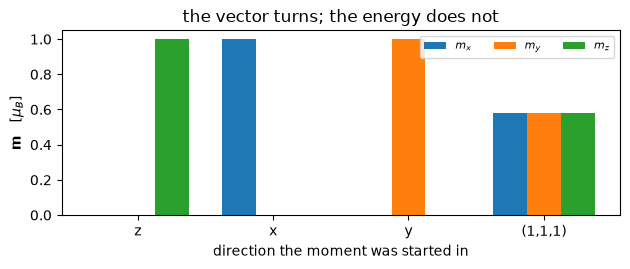

In [4]:
fig, ax = plt.subplots(figsize=(6.4, 2.8))
width, offsets = 0.25, np.arange(len(directions))
for component, colour in enumerate("C0 C1 C2".split()):
    ax.bar(offsets + (component - 1) * width,
           [moments[k][component] for k in directions], width,
           color=colour, label="$m_{}$".format("xyz"[component]))
ax.set_xticks(offsets)
ax.set_xticklabels(list(directions))
ax.set_xlabel("direction the moment was started in")
ax.set_ylabel(r"$\mathbf{m}$   [$\mu_B$]")
ax.set_title("the vector turns; the energy does not")
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()

The bars turn and the energies do not: four directions spread by 5e-11 Ry, and
the one along $z$ agrees with the genuinely collinear `nspin = 2` run to 3e-11.
Both are round-off on a total near $-0.95$ Ry.

## Constraining the moment

A constraint adds a penalty for the moment being somewhere other than where it
is wanted, and the field it produces is the derivative of that penalty. Four
schemes are available: constrain the total moment, the moment on each atom, its
direction only, or the total direction. All three that QE ships an input for:

In [5]:
rows = []
for name, scheme in (("noncolin-constrain_atomic", "atomic"),
                     ("noncolin-constrain_angle", "atomic direction"),
                     ("noncolin-constrain_total", "total")):
    result = Calculator.from_file(QE / f"{name}.in", pseudo_dir=PSEUDO,
                                  conv_thr=1e-11).get_scf()
    theirs = read_qe_output(REFS / f"reference.out.pw_noncolin-{name}")
    rows.append((scheme, result.total_energy, theirs.total_energy))

print(comparison_table(rows, fmt="{:.8f}",
                       headers=("scheme", "pypresso [Ry]", "pw.x", "difference")))

scheme            pypresso [Ry]          pw.x  difference
atomic             -55.69055703  -55.69055687     1.6e-07
atomic direction   -55.69968434  -55.69968434     2.7e-09
total              -55.54266107  -55.54266124     1.7e-07


**The constraint's energy is not part of the reported total.** The penalty is a
device for reaching a state, not a term in the material's energy, so it is
carried and printed separately. Elk excludes its external field's energy by the
same convention, and QE prints its `etcon` and adds it to nothing.

There is also a field whose job is to leave. Nothing in the SCF breaks spin
symmetry on its own, so an unpolarized starting guess stays unpolarized forever;
apply a field, halve it every iteration and let it vanish, and the run lands on
the magnetic solution to 1e-10 Ry with a genuine *zero-field* state at the end,
which a field left switched on would not give. That is Elk's `reducebf`, reached
here through a `LOCAL_MAGNETIC_FIELDS` card that `pw.x` has no counterpart for.

## What it refuses

**Spin-orbit coupling together with a spin spiral**, permanently: a spiral rests
on the generalized Bloch theorem and spin-orbit coupling breaks it, and Elk
refuses the same combination. A spiral also needs `nosym` and the whole k-grid
until the spin space group is written, and it needs a norm-conserving dataset.
In the linear response, **noncollinear magnetism** is refused by name: its
density response is a second implementation rather than a spin axis on the
existing one.

---
The tests behind this notebook: `tests/regression/test_noncollinear.py`,
`tests/regression/test_magnetic_constraints.py`, and
`tests/unit/test_magnetic_fields.py`, which checks the differentiated penalty
field against QE's hand-derived algebra for all four schemes.